<a href="https://colab.research.google.com/github/AnNguyenUwU/excercise-1/blob/main/FaceIdentify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_dir = "/content/drive/MyDrive/facetrain/FACE_RAP001_K51"

img_width, img_height = 100,100
batch_size = 32
train_datagen = ImageDataGenerator(rescale = 1.0/255,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip=True,
                                   fill_mode="nearest")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(100, 100),
    batch_size=batch_size,
    class_mode = "categorical"
)
model = Sequential([
    Conv2D(32,(3,3), activation = "relu", input_shape = (100,100,3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation = "relu"),
    MaxPooling2D(2,2),
    Conv2D(128,(3,3), activation = "relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation ='relu'),
    Dropout(0.5),
    Dense(25,activation="softmax")])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(train_generator,epochs = 10)
plt.plot(history.history['accuracy'], label="Ket qua huan luyen")
plt.xlabel("So lan hoc")
plt.ylabel("Do chinh xac")
plt.legend()
plt.show()

In [ ]:
model.save("training.h5")

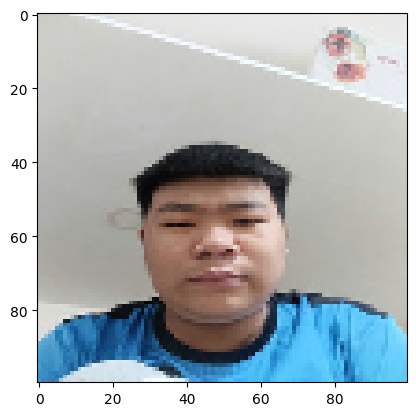

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
Nguoi tien doan:trần trí khang


In [ ]:
from keras.utils import load_img
from keras.models import load_model
import numpy as np
model = load_model("training.h5")
path = "/content/z7843675378671_52b855d7b582382bafea5c6859321044.jpg"
img = load_img(path, target_size=(100,100))
plt.imshow(img)
plt.show()
img = np.array(img)
img = img/255
img = img.reshape(1,100,100,3)
prediction = np.argmax(model.predict(img))
class_labels = {v:k for k,v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Nguoi tien doan:{person_name}")